Columns: Index(['currency', 'base_currency', 'currency_name', 'exchange_rate', 'date'], dtype='object')


,currency,base_currency,currency_name,exchange_rate,date
0,ZWL,EUR,Zimbabwean Dollar,373.047287,2025-10-10
1,GHS,EUR,Ghanaian Cedi,14.306725,2025-10-10
2,HRK,EUR,Croatian Kuna,7.533907,2025-10-10
3,HNL,EUR,Honduran Lempira,30.525553,2025-10-10
4,HKD,EUR,Hong Kong Dollar,9.015383,2025-10-10


Data types:
currency          object
base_currency     object
currency_name     object
exchange_rate    float64
date              object
dtype: object


C:\Users\hamma\AppData\Local\Temp\ipykernel_20848\2014275739.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_wide.fillna(method='ffill', inplace=True)


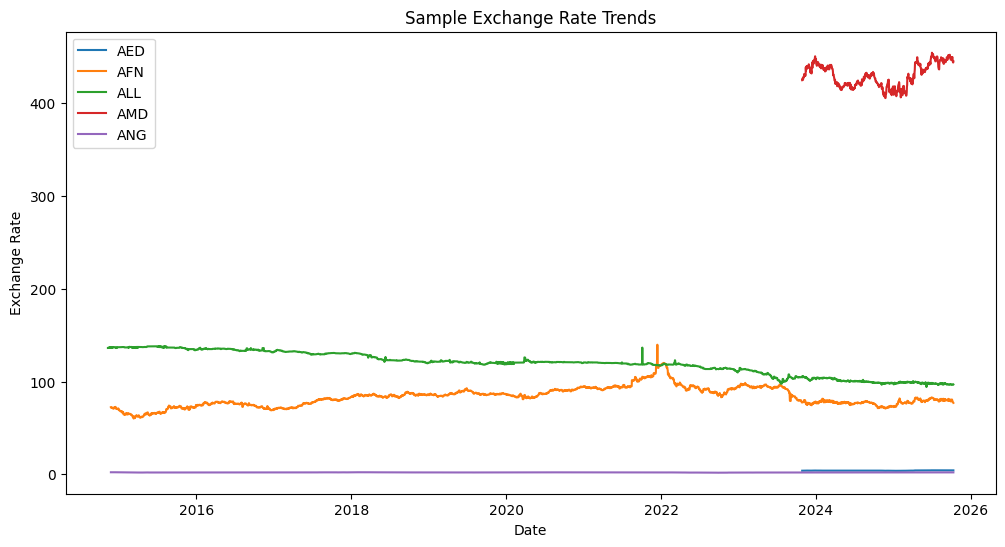

Cleaned dataset saved as 'exchange_rates_clean.csv'


In [1]:
# 01_data_preprocessing.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/daily_forex_rates.csv")

# Inspect data
print("Columns:", df.columns)
display(df.head())
print("Data types:")
print(df.dtypes)

# Drop rows where date or exchange_rate is missing
df = df.dropna(subset=['date', 'exchange_rate'])

# Convert 'date' to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows where conversion failed
df = df.dropna(subset=['date'])

# Pivot the data to wide format: rows = dates, columns = currency
df_wide = df.pivot(index='date', columns='currency', values='exchange_rate')

# Sort by date
df_wide.sort_index(inplace=True)

# Forward-fill missing values
df_wide.fillna(method='ffill', inplace=True)

# Quick plot for sample currencies
plt.figure(figsize=(12,6))
sample_currencies = df_wide.columns[:5]  # first 5 currencies as example
for col in sample_currencies:
    plt.plot(df_wide.index, df_wide[col], label=col)

plt.title("Sample Exchange Rate Trends")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

# Save cleaned dataset
df_wide.to_csv("../data/exchange_rates_clean.csv")
print("Cleaned dataset saved as 'exchange_rates_clean.csv'")


In [2]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("../data/exchange_rates_clean.csv", index_col=0, parse_dates=True)

# Check the data
display(df.head())
print(df.shape)


,AED,AFN,ALL,AMD,ANG,AOA,ARS,AUD,AWG,AZN,...,XCD,XCG,XDR,XOF,XPF,YER,ZAR,ZMK,ZMW,ZWL
date,,,,,,,,,,,,,,,,,,,,,
2004-08-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.7237,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.7296,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.7315,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.7474,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-09-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.7459,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(6234, 174)


In [3]:
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (4987, 174)
Test shape: (1247, 174)


In [4]:
currency = 'INR'  # replace with your column name
y_train = train_df[currency]
y_test = test_df[currency]


C:\Users\hamma\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hamma\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hamma\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\hamma\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting

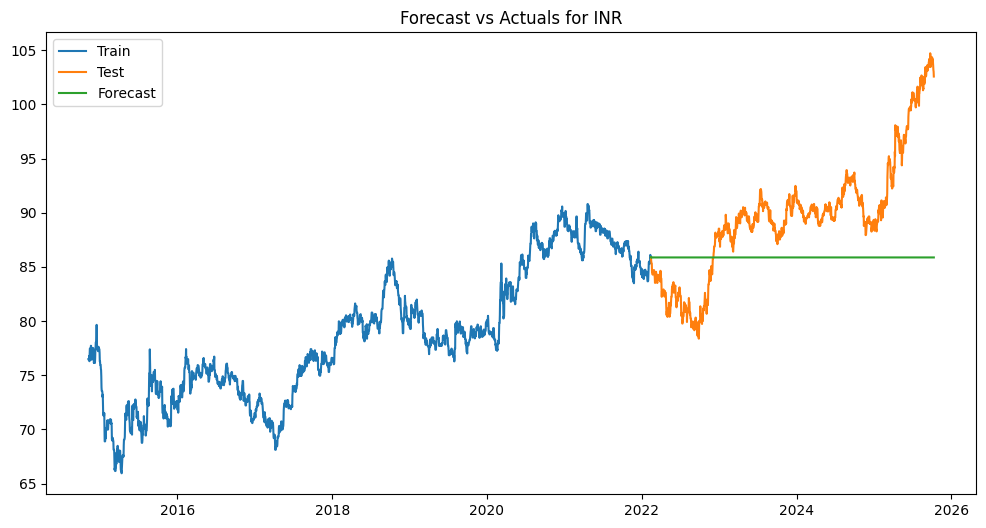

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Example SARIMAX model (start simple)
model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(0,0,0,0))
model_fit = model.fit(disp=False)

# Forecast
forecast_steps = len(y_test)
y_pred = model_fit.forecast(steps=forecast_steps)

# Compare with test set
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test')
plt.plot(y_test.index, y_pred, label='Forecast')
plt.legend()
plt.title(f"Forecast vs Actuals for {currency}")
plt.show()


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")


MAE: 5.6233, RMSE: 6.9262


In [7]:
forecasts = {}

for currency in df.columns:
    y_train = train_df[currency]
    y_test = test_df[currency]
    
    # Simple SARIMAX model
    model = SARIMAX(y_train, order=(1,1,1))
    model_fit = model.fit(disp=False)
    
    y_pred = model_fit.forecast(steps=len(y_test))
    
    forecasts[currency] = y_pred


C:\Users\hamma\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hamma\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hamma\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hamma\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is avail

In [8]:
forecast_df = pd.DataFrame(forecasts, index=test_df.index)
forecast_df.to_csv("../data/forecasts.csv")
print("Forecasts saved!")


Forecasts saved!


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Model Performance Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")


Model Performance Metrics:
MAE  : 9.8182
MSE  : 214.4537
RMSE : 14.6442
MAPE : nan%


C:\Users\hamma\AppData\Local\Temp\ipykernel_20848\2547313993.py:7: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
